# Optimization Note 5: Nonlinear Constraints

**Goal:** Extend the primal-dual IPM to the general nonlinear programming (NLP) problem with nonlinear equality and inequality constraints.

## The General NLP

$$\min_{x \in \mathbb{R}^n} f(x)$$
$$\text{s.t.} \quad g_L \leq g(x) \leq g_U$$
$$\phantom{\text{s.t.}} \quad x_L \leq x \leq x_U$$

This is the problem formulation that IPOPT and ripopt solve. It covers:
- **Equalities:** set $g_{L,j} = g_{U,j}$
- **One-sided inequalities:** set one bound to $\pm \infty$
- **Two-sided inequalities:** both bounds finite
- **Free variables:** set $x_L = -\infty, x_U = +\infty$

## Handling Inequalities: Slack Variables

Convert inequality $g_j(x) \leq g_{U,j}$ to equality by introducing a slack $s_j \geq 0$:

$$g_j(x) + s_j = g_{U,j}, \quad s_j \geq 0$$

Now the barrier applies to the slack: $-\mu \ln(s_j)$.

The beauty of this approach: **every NLP reduces to equality constraints plus bounds**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=6, suppress=True)

## The Full KKT System

For the general NLP with bounds on both $x$ and constraint slacks, the KKT system becomes:

$$\begin{bmatrix} H + \Sigma_x & J^T \\ J & -\Sigma_s^{-1} \end{bmatrix} \begin{bmatrix} \Delta x \\ \Delta y \end{bmatrix} = -\begin{bmatrix} r_d \\ r_p \end{bmatrix}$$

where:
- $H = \nabla^2_{xx} \mathcal{L}$ = Hessian of Lagrangian
- $\Sigma_x$ = barrier diagonal for variable bounds
- $\Sigma_s^{-1}$ = barrier diagonal for constraint slacks (makes $(2,2)$ block negative!)
- $J$ = constraint Jacobian
- $r_d$ = dual residual (stationarity violation)
- $r_p$ = primal residual (constraint violation)

### The Lagrangian

$$\mathcal{L}(x, y) = f(x) + \sum_j y_j \, g_j(x)$$

Its Hessian includes **second-order constraint information**:

$$H = \nabla^2 f(x) + \sum_j y_j \nabla^2 g_j(x)$$

This is why we need the Hessian of each constraint, not just the Jacobian.

In [2]:
class NLPProblem:
    """A simple NLP problem definition."""
    
    def __init__(self, n, m):
        self.n = n  # variables
        self.m = m  # constraints
        self.x_lower = np.full(n, -np.inf)
        self.x_upper = np.full(n, np.inf)
        self.g_lower = np.full(m, -np.inf)
        self.g_upper = np.full(m, np.inf)


def solve_nlp(problem, f, grad_f, hess_lag, g, jac_g, x0,
              mu_init=1.0, tol=1e-8, max_iter=300, kappa_mu=0.2):
    """Primal-dual IPM for general NLP using the full augmented system.
    
    Approach (same as IPOPT):
    1. Convert inequality g_L <= g(x) <= g_U to equality g(x) - s = 0
       with bounds on the slack: g_L <= s <= g_U
    2. Apply log barrier to all bounds (on x and s)
    3. Solve the Newton system on the barrier KKT conditions
    
    The augmented system has the structure:
    
        [H + Sigma_x,  0,        J^T  ] [dx]   [rhs_x]
        [0,            Sigma_s,  -I   ] [ds] = [rhs_s]
        [J,           -I,         0   ] [dy]   [rhs_c]
    
    Uses IPOPT's "monotone" strategy: solve each barrier subproblem
    (approximately) before decreasing mu. This ensures feasibility is
    maintained as the barrier parameter shrinks.
    """
    n = problem.n
    m = problem.m
    xl, xu = problem.x_lower, problem.x_upper
    gl, gu = problem.g_lower, problem.g_upper
    SMIN = 1e-14
    
    x = np.array(x0, dtype=float)
    for i in range(n):
        if np.isfinite(xl[i]): x[i] = max(x[i], xl[i] + 0.01)
        if np.isfinite(xu[i]): x[i] = min(x[i], xu[i] - 0.01)
    
    is_eq = np.array([gl[j] == gu[j] for j in range(m)])
    has_xl = np.isfinite(xl)
    has_xu = np.isfinite(xu)
    
    n_ineq = int(np.sum(~is_eq))
    ineq_idx = np.where(~is_eq)[0]
    
    # Initialize slacks
    gval = g(x)
    s = np.zeros(n_ineq)
    s_lower = np.zeros(n_ineq)
    s_upper = np.full(n_ineq, np.inf)
    has_sl = np.zeros(n_ineq, dtype=bool)
    has_su = np.zeros(n_ineq, dtype=bool)
    for k_s, j in enumerate(ineq_idx):
        s[k_s] = gval[j]
        if np.isfinite(gl[j]): s_lower[k_s] = gl[j]; has_sl[k_s] = True; s[k_s] = max(s[k_s], gl[j] + 0.01)
        if np.isfinite(gu[j]): s_upper[k_s] = gu[j]; has_su[k_s] = True; s[k_s] = min(s[k_s], gu[j] - 0.01)
    
    mu = mu_init
    zl_x = np.where(has_xl, mu / np.maximum(x - xl, 0.01), 0.0)
    zu_x = np.where(has_xu, mu / np.maximum(xu - x, 0.01), 0.0)
    zl_s = np.where(has_sl, mu / np.maximum(s - s_lower, 0.01), 0.0)
    zu_s = np.where(has_su, mu / np.maximum(s_upper - s, 0.01), 0.0)
    y = np.zeros(m)
    
    history = []
    N = n + n_ineq + m
    
    for iteration in range(max_iter):
        gval = g(x); gf = grad_f(x); J = jac_g(x); H = hess_lag(x, y)
        
        sl_x = np.where(has_xl, np.maximum(x - xl, SMIN), 1.0)
        su_x = np.where(has_xu, np.maximum(xu - x, SMIN), 1.0)
        sl_s = np.where(has_sl, np.maximum(s - s_lower, SMIN), 1.0)
        su_s = np.where(has_su, np.maximum(s_upper - s, SMIN), 1.0)
        
        sigma_x = np.zeros(n)
        for i in range(n):
            if has_xl[i]: sigma_x[i] += zl_x[i] / sl_x[i]
            if has_xu[i]: sigma_x[i] += zu_x[i] / su_x[i]
        
        sigma_s_diag = np.zeros(n_ineq)
        for k_s in range(n_ineq):
            if has_sl[k_s]: sigma_s_diag[k_s] += zl_s[k_s] / sl_s[k_s]
            if has_su[k_s]: sigma_s_diag[k_s] += zu_s[k_s] / su_s[k_s]
        
        # Convergence
        r_x = gf + J.T @ y
        for i in range(n):
            if has_xl[i]: r_x[i] -= zl_x[i]
            if has_xu[i]: r_x[i] += zu_x[i]
        
        r_s = np.zeros(n_ineq)
        for k_s, j in enumerate(ineq_idx):
            r_s[k_s] = -y[j]
            if has_sl[k_s]: r_s[k_s] -= zl_s[k_s]
            if has_su[k_s]: r_s[k_s] += zu_s[k_s]
        
        r_c = np.zeros(m)
        for j in range(m):
            if is_eq[j]: r_c[j] = gval[j] - gl[j]
            else:
                k_s = int(np.searchsorted(ineq_idx, j))
                r_c[j] = gval[j] - s[k_s]
        
        compl = 0.0
        for i in range(n):
            if has_xl[i]: compl = max(compl, zl_x[i] * sl_x[i])
            if has_xu[i]: compl = max(compl, zu_x[i] * su_x[i])
        for k_s in range(n_ineq):
            if has_sl[k_s]: compl = max(compl, zl_s[k_s] * sl_s[k_s])
            if has_su[k_s]: compl = max(compl, zu_s[k_s] * su_s[k_s])
        
        dual_inf = max(np.linalg.norm(r_x, np.inf),
                       np.linalg.norm(r_s, np.inf) if n_ineq > 0 else 0.0)
        primal_inf = np.linalg.norm(r_c, np.inf)
        
        history.append({
            'x': x.copy(), 'f': f(x), 'mu': mu,
            'dual_inf': dual_inf, 'primal_inf': primal_inf, 'compl': compl
        })
        
        if dual_inf < tol and primal_inf < tol and compl < tol:
            break
        
        # Decrease mu only when barrier subproblem is approximately solved
        barrier_tol = max(mu, tol)
        if dual_inf < barrier_tol and primal_inf < barrier_tol:
            mu = max(kappa_mu * mu, 1e-12)
            # Re-initialize bound multipliers to stay centered
            for i in range(n):
                if has_xl[i]: zl_x[i] = mu / sl_x[i]
                if has_xu[i]: zu_x[i] = mu / su_x[i]
            for k_s in range(n_ineq):
                if has_sl[k_s]: zl_s[k_s] = mu / sl_s[k_s]
                if has_su[k_s]: zu_s[k_s] = mu / su_s[k_s]
            continue  # re-evaluate with new mu
        
        # Build KKT
        KKT = np.zeros((N, N))
        KKT[:n, :n] = H + np.diag(sigma_x)
        for k_s in range(n_ineq):
            KKT[n + k_s, n + k_s] = sigma_s_diag[k_s]
        KKT[n + n_ineq:, :n] = J
        KKT[:n, n + n_ineq:] = J.T
        for k_s, j in enumerate(ineq_idx):
            KKT[n + n_ineq + j, n + k_s] = -1.0
            KKT[n + k_s, n + n_ineq + j] = -1.0
        
        # Inertia correction
        eigs = np.linalg.eigvalsh(KKT[:n, :n])
        if eigs[0] < 1e-6:
            delta = max(1e-4, -eigs[0] + 1e-4)
            KKT[:n, :n] += delta * np.eye(n)
        
        # RHS
        rhs = np.zeros(N)
        rhs[:n] = -gf - J.T @ y
        for i in range(n):
            if has_xl[i]: rhs[i] += mu / sl_x[i]
            if has_xu[i]: rhs[i] -= mu / su_x[i]
        for k_s, j in enumerate(ineq_idx):
            rhs[n + k_s] = y[j]
            if has_sl[k_s]: rhs[n + k_s] += mu / sl_s[k_s]
            if has_su[k_s]: rhs[n + k_s] -= mu / su_s[k_s]
        for j in range(m):
            rhs[n + n_ineq + j] = -r_c[j]
        
        sol = np.linalg.solve(KKT, rhs)
        dx = sol[:n]; ds = sol[n:n + n_ineq]; dy = sol[n + n_ineq:]
        
        dzl_x = np.zeros(n); dzu_x = np.zeros(n)
        for i in range(n):
            if has_xl[i]: dzl_x[i] = mu / sl_x[i] - zl_x[i] - (zl_x[i] / sl_x[i]) * dx[i]
            if has_xu[i]: dzu_x[i] = mu / su_x[i] - zu_x[i] + (zu_x[i] / su_x[i]) * dx[i]
        
        dzl_s = np.zeros(n_ineq); dzu_s = np.zeros(n_ineq)
        for k_s in range(n_ineq):
            if has_sl[k_s]: dzl_s[k_s] = mu / sl_s[k_s] - zl_s[k_s] - (zl_s[k_s] / sl_s[k_s]) * ds[k_s]
            if has_su[k_s]: dzu_s[k_s] = mu / su_s[k_s] - zu_s[k_s] + (zu_s[k_s] / su_s[k_s]) * ds[k_s]
        
        tau = max(0.99, 1 - mu)
        alpha_p = 1.0
        for i in range(n):
            if has_xl[i] and dx[i] < 0: alpha_p = min(alpha_p, -tau * sl_x[i] / dx[i])
            if has_xu[i] and dx[i] > 0: alpha_p = min(alpha_p, tau * su_x[i] / dx[i])
        for k_s in range(n_ineq):
            if has_sl[k_s] and ds[k_s] < 0: alpha_p = min(alpha_p, -tau * sl_s[k_s] / ds[k_s])
            if has_su[k_s] and ds[k_s] > 0: alpha_p = min(alpha_p, tau * su_s[k_s] / ds[k_s])
        
        alpha_d = 1.0
        for i in range(n):
            if has_xl[i] and dzl_x[i] < 0: alpha_d = min(alpha_d, -tau * zl_x[i] / dzl_x[i])
            if has_xu[i] and dzu_x[i] < 0: alpha_d = min(alpha_d, -tau * zu_x[i] / dzu_x[i])
        for k_s in range(n_ineq):
            if has_sl[k_s] and dzl_s[k_s] < 0: alpha_d = min(alpha_d, -tau * zl_s[k_s] / dzl_s[k_s])
            if has_su[k_s] and dzu_s[k_s] < 0: alpha_d = min(alpha_d, -tau * zu_s[k_s] / dzu_s[k_s])
        
        x += alpha_p * dx; s += alpha_p * ds
        for i in range(n):
            if has_xl[i]: x[i] = max(x[i], xl[i] + SMIN)
            if has_xu[i]: x[i] = min(x[i], xu[i] - SMIN)
        for k_s in range(n_ineq):
            if has_sl[k_s]: s[k_s] = max(s[k_s], s_lower[k_s] + SMIN)
            if has_su[k_s]: s[k_s] = min(s[k_s], s_upper[k_s] - SMIN)
        
        y += alpha_d * dy
        zl_x = np.maximum(zl_x + alpha_d * dzl_x, SMIN * np.where(has_xl, 1, 0))
        zu_x = np.maximum(zu_x + alpha_d * dzu_x, SMIN * np.where(has_xu, 1, 0))
        zl_s = np.maximum(zl_s + alpha_d * dzl_s, SMIN * np.where(has_sl, 1, 0))
        zu_s = np.maximum(zu_s + alpha_d * dzu_s, SMIN * np.where(has_su, 1, 0))
    
    return x, y, history

## Example: HS071 — The Classic IPOPT Test Problem

This is the canonical test problem for interior point solvers:

$$\min \; x_1 x_4 (x_1 + x_2 + x_3) + x_3$$
$$\text{s.t.} \quad x_1 x_2 x_3 x_4 \geq 25$$
$$\phantom{\text{s.t.}} \quad x_1^2 + x_2^2 + x_3^2 + x_4^2 = 40$$
$$\phantom{\text{s.t.}} \quad 1 \leq x_i \leq 5$$

In [3]:
# HS071
prob = NLPProblem(n=4, m=2)
prob.x_lower = np.array([1.0, 1.0, 1.0, 1.0])
prob.x_upper = np.array([5.0, 5.0, 5.0, 5.0])
prob.g_lower = np.array([25.0, 40.0])
prob.g_upper = np.array([np.inf, 40.0])  # g1 >= 25, g2 = 40

def f71(x):
    return x[0] * x[3] * (x[0] + x[1] + x[2]) + x[2]

def grad_f71(x):
    return np.array([
        x[3] * (2*x[0] + x[1] + x[2]),
        x[0] * x[3],
        x[0] * x[3] + 1,
        x[0] * (x[0] + x[1] + x[2])
    ])

def g71(x):
    return np.array([
        x[0] * x[1] * x[2] * x[3],  # >= 25
        x[0]**2 + x[1]**2 + x[2]**2 + x[3]**2  # = 40
    ])

def jac_g71(x):
    return np.array([
        [x[1]*x[2]*x[3], x[0]*x[2]*x[3], x[0]*x[1]*x[3], x[0]*x[1]*x[2]],
        [2*x[0], 2*x[1], 2*x[2], 2*x[3]]
    ])

def hess_lag71(x, y):
    H = np.zeros((4, 4))
    # Objective Hessian
    H[0, 0] = 2 * x[3]
    H[0, 1] = x[3]; H[1, 0] = x[3]
    H[0, 2] = x[3]; H[2, 0] = x[3]
    H[0, 3] = 2*x[0] + x[1] + x[2]; H[3, 0] = H[0, 3]
    H[1, 3] = x[0]; H[3, 1] = x[0]
    H[2, 3] = x[0]; H[3, 2] = x[0]
    
    # Constraint 1 Hessian (x1*x2*x3*x4) * y[0]
    if len(y) > 0:
        H[0, 1] += y[0] * x[2]*x[3]; H[1, 0] = H[0, 1]
        H[0, 2] += y[0] * x[1]*x[3]; H[2, 0] = H[0, 2]
        H[0, 3] += y[0] * x[1]*x[2]; H[3, 0] = H[0, 3]
        H[1, 2] += y[0] * x[0]*x[3]; H[2, 1] = H[1, 2]
        H[1, 3] += y[0] * x[0]*x[2]; H[3, 1] = H[1, 3]
        H[2, 3] += y[0] * x[0]*x[1]; H[3, 2] = H[2, 3]
    
    # Constraint 2 Hessian (sum of squares) * y[1]
    if len(y) > 1:
        for i in range(4):
            H[i, i] += 2 * y[1]
    
    return H


# Start from a feasible point: g1 = 2*4*4*2 = 64 >= 25, g2 = 4+16+16+4 = 40
# (The standard start x0=[1,5,5,1] is deeply infeasible for the equality,
#  requiring filter line search / restoration — covered in Note 6.)
x0 = np.array([2.0, 4.0, 4.0, 2.0])
x_opt, y_opt, hist = solve_nlp(prob, f71, grad_f71, hess_lag71, g71, jac_g71, x0)

print(f"Solution: x = {x_opt}")
print(f"f(x*) = {f71(x_opt):.6f}")
print(f"g(x*) = {g71(x_opt)}")
print(f"y = {y_opt}")
print(f"Iterations: {len(hist)}")
print(f"\nExpected: x ≈ [1.0, 4.743, 3.821, 1.379]")
print(f"Expected: f ≈ 17.014")

Solution: x = [1.       4.743    3.82115  1.379408]
f(x*) = 17.014017
g(x*) = [25. 40.]
y = [-0.552294  0.161469]
Iterations: 121

Expected: x ≈ [1.0, 4.743, 3.821, 1.379]
Expected: f ≈ 17.014


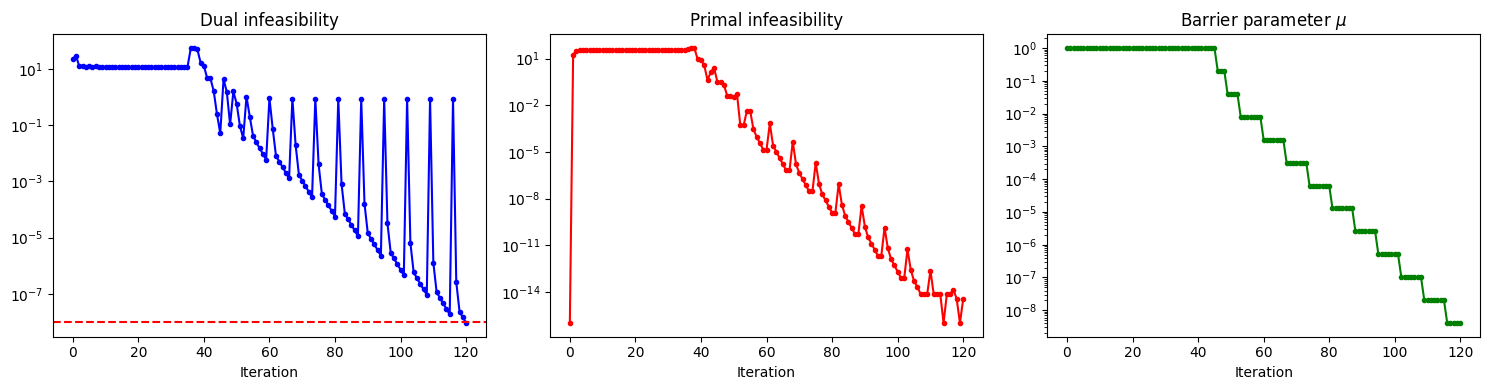

In [4]:
# Convergence history
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

iters = range(len(hist))

axes[0].semilogy(iters, [h['dual_inf'] for h in hist], 'b.-')
axes[0].set_title('Dual infeasibility')
axes[0].set_xlabel('Iteration')
axes[0].axhline(y=tol if 'tol' in dir() else 1e-8, color='r', linestyle='--', label='tol')

axes[1].semilogy(iters, [max(h['primal_inf'], 1e-16) for h in hist], 'r.-')
axes[1].set_title('Primal infeasibility')
axes[1].set_xlabel('Iteration')

axes[2].semilogy(iters, [h['mu'] for h in hist], 'g.-')
axes[2].set_title('Barrier parameter $\\mu$')
axes[2].set_xlabel('Iteration')

plt.tight_layout()
plt.show()

## The Filter Line Search

With constraints, we have two competing objectives:
1. Decrease $f(x)$ (optimality)
2. Decrease $\|c(x)\|$ (feasibility)

A simple merit function combines them, but choosing the penalty weight is difficult.

The **filter method** (used by IPOPT and ripopt) avoids this by maintaining a set of "acceptable" $(\theta, \varphi)$ pairs:
- $\theta = \|c(x)\|$ (constraint violation)
- $\varphi = f(x) + \text{barrier terms}$ (barrier objective)

A trial point is accepted if it **dominates** at least one entry in the filter — either less constraint violation OR better objective. This is like Pareto optimality in multi-objective optimization.

ripopt's filter combines this with an **Armijo-type switching condition**: if the constraint violation is already small, require sufficient decrease in $\varphi$ instead.

## The Full Problem Interface

Here's what a solver needs from the user for a general NLP. This is essentially the IPOPT/ripopt problem interface:

| Callback | Returns | Cost |
|---|---|---|
| `objective(x)` | $f(x)$ | $O(n)$ typically |
| `gradient(x)` | $\nabla f(x)$ | $O(n)$ |
| `constraints(x)` | $g(x)$ | $O(m)$ |
| `jacobian(x)` | $J(x) = \nabla g(x)^T$ | $O(\text{nnz}(J))$ |
| `hessian(x, y)` | $\nabla^2_{xx} \mathcal{L}(x,y)$ | $O(\text{nnz}(H))$ |
| `bounds` | $x_L, x_U, g_L, g_U$ | Once |

The Jacobian and Hessian are typically **sparse** — and their sparsity pattern is fixed across iterations. This is why the symbolic analysis from the linear solver series (Note 5) is so valuable: analyze the pattern once, refactor cheaply at every iteration.

## What We've Learned

1. **Slack variables** convert inequalities to equalities + bounds: all NLPs reduce to this form
2. The **Lagrangian Hessian** $H = \nabla^2 f + \sum y_j \nabla^2 g_j$ includes second-order constraint information
3. The **KKT matrix** has a $(2,2)$ block from constraint slack barriers, making it indefinite
4. The **filter line search** handles the two competing objectives (optimality vs feasibility) without penalty parameters
5. The problem interface is: objective, gradient, constraints, Jacobian, Hessian, bounds

## What's Next

Our IPM works on well-behaved problems. But real problems are messy: the Hessian may be indefinite, the KKT system may be singular, the starting point may be deeply infeasible. In Note 6, we cover the **robustness machinery** that makes the difference between a textbook algorithm and a production solver: inertia correction, regularization, and restoration.

---

*This is Optimization Note 5 in a series building from Newton's method to the interior point optimizer [ripopt](https://github.com/jkitchin/ripopt).*